## 1. Configuración del modelo

In [1]:
# CONFIGURACIÓN DEL MODELO
MODEL_ID = "utter-project/EuroLLM-9B-Instruct"
MODEL_SHORT_NAME = "eurollm_9b_instruct"

MODEL_TYPE = "causal_lm"              # arquitectura Llama estándar, no tiene visión
SUPPORTS_ENABLE_THINKING = False      # este modleo tampoco tiene modo thinking

# Configuración general
# ============================
SEED = 42
MAX_NEW_TOKENS = 10        # la respuesta esperada es solo la etiqueta, no necesitamos generar mucho texto
TEMPERATURE = 0.0          # determinismo: queremos la respuesta más probable, no variabilidad creativa
DO_SAMPLE = False          # con temperature=0 y do_sample=False, la generación es reproducible

RUTA_VAL = "/content/val_final.csv"
RUTA_TEST = "/content/test_final.csv"

CHECKPOINT_CADA = 200      # cada cuántos ejemplos se guarda un checkpoint parcial durante el loop


## 2. Instalación de dependencias


In [2]:
#!pip install -q "transformers==5.10.4" accelerate "kernels==0.10.3"

import transformers
print("Versión de transformers instalada:", transformers.__version__)

import torch
print("Versión de torch instalada:", torch.__version__)
print("Versión de CUDA (torch):", torch.version.cuda)


Versión de transformers instalada: 5.13.1
Versión de torch instalada: 2.11.0+cu128
Versión de CUDA (torch): 12.8


## 3. Verificación de GPU

In [3]:
print("GPU disponible:", torch.cuda.is_available())
print("Nombre GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A")


GPU disponible: True
Nombre GPU: NVIDIA L4


## 4. Login a Hugging Face

In [4]:
from google.colab import userdata
from huggingface_hub import login

hf_token = userdata.get("HF_TOKEN")
login(token=hf_token)

print("Login exitoso")


Login exitoso


## 5. Cargar el dataset de validación

In [5]:
import pandas as pd

df_val = pd.read_csv(RUTA_VAL)

print("Validation cargado:", df_val.shape)
print(df_val["label_name"].value_counts())
df_val.head()


Validation cargado: (1454, 4)
label_name
negative    663
positive    473
neutral     318
Name: count, dtype: int64


,text,text_clean,label,label_name
0,"Daniella, un sanguchito de pavo en Astoria y l...","Daniella, un sanguchito de pavo en Astoria y l...",2,positive
1,Cocoros 🙂. Cuando vivía en talara era mi punto.,Cocoros 🙂. Cuando vivía en talara era mi punto.,1,neutral
2,Jaja se elegierón los corruptos al asu aliado ...,Jaja se elegierón los corruptos al asu aliado ...,0,negative
3,"Fatima, la caminada en tacos fue todo! Ya me...","Fatima, la caminada en tacos fue todo! Ya me v...",1,neutral
4,"El injerto resollaba, emitía grititos destempl...","El injerto resollaba, emitía grititos destempl...",0,negative


## 6. Definición de los 5 prompts (Tabla 6)

In [6]:
PROMPTS = {
    1: {
        "system": None,
        "user": "Clasifica el sentimiento del siguiente comentario. Responde solo con una de estas palabras: negativo, neutral, positivo. Comentario: {text}"
    },
    2: {
        "system": None,
        "user": "Para el texto proporcionado, analiza su sentimiento y clasifícalo únicamente en una de las siguientes clases: negativo, neutral, positivo. Texto: {text}"
    },
    3: {
        "system": None,
        "user": "Clasifica el sentimiento del texto en español peruano informal en solo una de las siguientes categorías: negativo, neutral, positivo. Texto: {text}"
    },
    4: {
        "system": "Eres un clasificador de sentimientos de comentarios en español peruano. Responde únicamente con una de las siguientes clases: negativo, neutral, positivo.",
        "user": "Clasifica el siguiente comentario. Comentario: {text}"
    },
    5: {
        "system": "Eres un experto en clasificar el sentimiento de textos que pueden contener jergas o expresiones coloquiales del español peruano. Responde únicamente con una de las siguientes clases: negativo, neutral, positivo. No brindes texto adicional.",
        "user": "Clasifica el siguiente texto. Texto: {text}"
    },
}

def construir_mensajes(prompt_id: int, texto: str):
    """Devuelve la lista de mensajes (formato chat) para un prompt_id y un texto dado."""
    config = PROMPTS[prompt_id]
    mensajes = []
    if config["system"] is not None:
        mensajes.append({"role": "system", "content": config["system"]})
    mensajes.append({"role": "user", "content": config["user"].format(text=texto)})
    return mensajes


texto_ejemplo = df_val.iloc[0]["text_clean"]
for pid in PROMPTS:
    print(f"--- Prompt {pid} ---")
    print(construir_mensajes(pid, texto_ejemplo))
    print()


--- Prompt 1 ---
[{'role': 'user', 'content': 'Clasifica el sentimiento del siguiente comentario. Responde solo con una de estas palabras: negativo, neutral, positivo. Comentario: Daniella, un sanguchito de pavo en Astoria y las empanadas de Sorrento...uuuffffff!!!! 😙👌'}]

--- Prompt 2 ---
[{'role': 'user', 'content': 'Para el texto proporcionado, analiza su sentimiento y clasifícalo únicamente en una de las siguientes clases: negativo, neutral, positivo. Texto: Daniella, un sanguchito de pavo en Astoria y las empanadas de Sorrento...uuuffffff!!!! 😙👌'}]

--- Prompt 3 ---
[{'role': 'user', 'content': 'Clasifica el sentimiento del texto en español peruano informal en solo una de las siguientes categorías: negativo, neutral, positivo. Texto: Daniella, un sanguchito de pavo en Astoria y las empanadas de Sorrento...uuuffffff!!!! 😙👌'}]

--- Prompt 4 ---
[{'role': 'system', 'content': 'Eres un clasificador de sentimientos de comentarios en español peruano. Responde únicamente con una de las s

## 7. Carga del modelo

Esta celda se adapta automáticamente según `MODEL_TYPE` definido en la Sección 1.

In [7]:
import time
import torch

print(f"Cargando modelo: {MODEL_ID}  (tipo: {MODEL_TYPE})")
t0 = time.time()

if MODEL_TYPE == "multimodal":
    from transformers import AutoProcessor, AutoModelForMultimodalLM

    processor = AutoProcessor.from_pretrained(MODEL_ID, token=hf_token)
    model = AutoModelForMultimodalLM.from_pretrained(
        MODEL_ID,
        torch_dtype=torch.bfloat16,
        device_map="auto",
        token=hf_token,
    )
    tokenizer = processor.tokenizer

elif MODEL_TYPE == "causal_lm":
    from transformers import AutoTokenizer, AutoModelForCausalLM

    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, token=hf_token)
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        torch_dtype=torch.bfloat16,
        device_map="auto",
        token=hf_token,
    )
    processor = None  # no aplica para modelos de solo texto

else:
    raise ValueError(f"MODEL_TYPE debe ser 'multimodal' o 'causal_lm', recibido: {MODEL_TYPE}")

tiempo_carga = time.time() - t0

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model.eval()

print(f"Modelo cargado en {tiempo_carga:.1f} segundos")
print(f"Memoria GPU reservada tras cargar: {torch.cuda.memory_reserved() / 1e9:.2f} GB")
print(f"Memoria GPU asignada tras cargar: {torch.cuda.memory_allocated() / 1e9:.2f} GB")


Cargando modelo: utter-project/EuroLLM-9B-Instruct  (tipo: causal_lm)


config.json:   0%|          | 0.00/756 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/47.3k [00:00<?, ?B/s]

tokenizer.model: reconstructing file:   0%|          |  0.00B / 2.41MB            

tokenizer.model: downloading bytes:           |  0.00B            

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/381 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

Modelo cargado en 79.1 segundos
Memoria GPU reservada tras cargar: 18.31 GB
Memoria GPU asignada tras cargar: 18.30 GB


In [8]:
import random
import numpy as np

def fijar_semilla(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

fijar_semilla(SEED)


## 8. Función de generación (unificada para ambos tipos de modelo)

Esta función abstrae la diferencia entre `processor.apply_chat_template` (multimodal) y `tokenizer.apply_chat_template` (causal_lm estándar), y entre modelos que soportan `enable_thinking` y los que no.

In [9]:
def generar_respuesta(mensajes):
    kwargs_template = dict(
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    )
    if SUPPORTS_ENABLE_THINKING:
        kwargs_template["enable_thinking"] = False

    if MODEL_TYPE == "multimodal":
        inputs = processor.apply_chat_template(mensajes, **kwargs_template).to(model.device)
    else:
        inputs = tokenizer.apply_chat_template(mensajes, **kwargs_template).to(model.device)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=DO_SAMPLE,
            pad_token_id=tokenizer.pad_token_id if tokenizer.pad_token_id is not None else tokenizer.eos_token_id,
        )

    respuesta = tokenizer.decode(output[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True)
    return respuesta


# Prueba rápida con un solo ejemplo antes de correr todo el dataset
mensajes_prueba = construir_mensajes(1, texto_ejemplo)
respuesta_prueba = generar_respuesta(mensajes_prueba)
print("--- Respuesta generada (prueba) ---")
print(repr(respuesta_prueba))


--- Respuesta generada (prueba) ---
'negativo'


## 9. Función de parseo de la respuesta a una de las 3 clases

In [10]:
import re
import unicodedata

def normalizar_texto(texto: str) -> str:
    texto = texto.lower().strip()
    texto = ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )
    return texto

def parsear_respuesta(respuesta: str) -> str:
    texto = normalizar_texto(respuesta)

    tiene_negativo = bool(re.search(r"\bnegativ", texto))
    tiene_neutral = bool(re.search(r"\bneutral", texto))
    tiene_positivo = bool(re.search(r"\bpositiv", texto))

    encontrados = [
        etiqueta for etiqueta, encontrado in
        [("negative", tiene_negativo), ("neutral", tiene_neutral), ("positive", tiene_positivo)]
        if encontrado
    ]

    if len(encontrados) == 1:
        return encontrados[0]
    else:
        return "invalido"


casos_prueba = ["positivo\n", "Negativo.", "La respuesta es: NEUTRAL", "no estoy seguro", "positivo o neutral"]
for caso in casos_prueba:
    print(f"{caso!r:40} -> {parsear_respuesta(caso)}")


'positivo\n'                             -> positive
'Negativo.'                              -> negative
'La respuesta es: NEUTRAL'               -> neutral
'no estoy seguro'                        -> invalido
'positivo o neutral'                     -> invalido


## 10. Loop de evaluación sobre validation (5 prompts), con logging completo

In [11]:
!pip install -q tqdm


In [12]:
import time
import torch
import pandas as pd
from tqdm.auto import tqdm

def evaluar_modelo_en_prompt(df, prompt_id, checkpoint_cada=CHECKPOINT_CADA, nombre_archivo=None):
    fijar_semilla(SEED)

    resultados = []
    torch.cuda.reset_peak_memory_stats()
    t_inicio = time.time()

    for idx, fila in tqdm(df.iterrows(), total=len(df), desc=f"Prompt {prompt_id}"):
        texto = fila["text_clean"]
        mensajes = construir_mensajes(prompt_id, texto)
        respuesta_cruda = generar_respuesta(mensajes)
        prediccion = parsear_respuesta(respuesta_cruda)

        resultados.append({
            "idx_original": idx,
            "text_clean": texto,
            "label_name": fila["label_name"],
            "prompt_id": prompt_id,
            "respuesta_cruda": respuesta_cruda,
            "prediccion": prediccion,
        })

        if nombre_archivo and (len(resultados) % checkpoint_cada == 0):
            pd.DataFrame(resultados).to_csv(nombre_archivo, index=False)

    tiempo_total = time.time() - t_inicio
    memoria_pico_gb = torch.cuda.max_memory_allocated() / 1e9

    df_resultados = pd.DataFrame(resultados)
    if nombre_archivo:
        df_resultados.to_csv(nombre_archivo, index=False)

    metadata = {
        "modelo": MODEL_ID,
        "prompt_id": prompt_id,
        "seed": SEED,
        "max_new_tokens": MAX_NEW_TOKENS,
        "temperature": TEMPERATURE,
        "do_sample": DO_SAMPLE,
        "n_ejemplos": len(df),
        "tiempo_total_seg": round(tiempo_total, 1),
        "tiempo_promedio_por_ejemplo_seg": round(tiempo_total / len(df), 3),
        "memoria_pico_gb": round(memoria_pico_gb, 2),
    }

    return df_resultados, metadata


In [13]:
resultados_por_prompt = {}
log_experimentos = []

for prompt_id in PROMPTS:
    nombre_archivo = f"val_{MODEL_SHORT_NAME}_prompt{prompt_id}.csv"
    df_res, metadata = evaluar_modelo_en_prompt(
        df_val, prompt_id, checkpoint_cada=CHECKPOINT_CADA, nombre_archivo=nombre_archivo
    )
    resultados_por_prompt[prompt_id] = df_res
    log_experimentos.append(metadata)
    print(f"Prompt {prompt_id} terminado -> {metadata}")

df_log = pd.DataFrame(log_experimentos)
df_log.to_csv(f"log_experimentos_{MODEL_SHORT_NAME}_validation.csv", index=False)
df_log


Prompt 1:   0%|          | 0/1454 [00:00<?, ?it/s]

Prompt 1 terminado -> {'modelo': 'utter-project/EuroLLM-9B-Instruct', 'prompt_id': 1, 'seed': 42, 'max_new_tokens': 10, 'temperature': 0.0, 'do_sample': False, 'n_ejemplos': 1454, 'tiempo_total_seg': 374.0, 'tiempo_promedio_por_ejemplo_seg': 0.257, 'memoria_pico_gb': 18.98}


Prompt 2:   0%|          | 0/1454 [00:00<?, ?it/s]

Prompt 2 terminado -> {'modelo': 'utter-project/EuroLLM-9B-Instruct', 'prompt_id': 2, 'seed': 42, 'max_new_tokens': 10, 'temperature': 0.0, 'do_sample': False, 'n_ejemplos': 1454, 'tiempo_total_seg': 1098.7, 'tiempo_promedio_por_ejemplo_seg': 0.756, 'memoria_pico_gb': 18.98}


Prompt 3:   0%|          | 0/1454 [00:00<?, ?it/s]

...

Prompt 4:   0%|          | 0/1454 [00:00<?, ?it/s]

Prompt 4 terminado -> {'modelo': 'utter-project/EuroLLM-9B-Instruct', 'prompt_id': 4, 'seed': 42, 'max_new_tokens': 10, 'temperature': 0.0, 'do_sample': False, 'n_ejemplos': 1454, 'tiempo_total_seg': 369.1, 'tiempo_promedio_por_ejemplo_seg': 0.254, 'memoria_pico_gb': 18.98}


Prompt 5:   0%|          | 0/1454 [00:00<?, ?it/s]

Prompt 5 terminado -> {'modelo': 'utter-project/EuroLLM-9B-Instruct', 'prompt_id': 5, 'seed': 42, 'max_new_tokens': 10, 'temperature': 0.0, 'do_sample': False, 'n_ejemplos': 1454, 'tiempo_total_seg': 369.1, 'tiempo_promedio_por_ejemplo_seg': 0.254, 'memoria_pico_gb': 18.98}


,modelo,prompt_id,seed,max_new_tokens,temperature,do_sample,n_ejemplos,tiempo_total_seg,tiempo_promedio_por_ejemplo_seg,memoria_pico_gb
0,utter-project/EuroLLM-9B-Instruct,1,42,10,0.0,False,1454,374.0,0.257,18.98
1,utter-project/EuroLLM-9B-Instruct,2,42,10,0.0,False,1454,1098.7,0.756,18.98
2,utter-project/EuroLLM-9B-Instruct,3,42,10,0.0,False,1454,583.8,0.402,18.98
3,utter-project/EuroLLM-9B-Instruct,4,42,10,0.0,False,1454,369.1,0.254,18.98
4,utter-project/EuroLLM-9B-Instruct,5,42,10,0.0,False,1454,369.1,0.254,18.98


## 11. Métricas por prompt y selección del mejor prompt para este modelo

In [15]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import pandas as pd

CLASES = ["negative", "neutral", "positive"]

def calcular_metricas(df_resultados, prompt_id):
    y_true = df_resultados["label_name"]
    y_pred = df_resultados["prediccion"]

    n_invalidos = (y_pred == "invalido").sum()
    pct_invalidos = round(100 * n_invalidos / len(df_resultados), 2)

    accuracy = accuracy_score(y_true, y_pred)  # robusto a etiquetas "invalido" fuera de CLASES

    reporte = classification_report(
        y_true, y_pred, labels=CLASES, output_dict=True, zero_division=0
    )
    macro_f1 = f1_score(y_true, y_pred, labels=CLASES, average="macro", zero_division=0)
    matriz = confusion_matrix(y_true, y_pred, labels=CLASES)

    resumen = {
        "prompt_id": prompt_id,
        "accuracy": round(accuracy, 4),
        "macro_f1": round(macro_f1, 4),
        "precision_negative": round(reporte["negative"]["precision"], 4),
        "recall_negative": round(reporte["negative"]["recall"], 4),
        "f1_negative": round(reporte["negative"]["f1-score"], 4),
        "precision_neutral": round(reporte["neutral"]["precision"], 4),
        "recall_neutral": round(reporte["neutral"]["recall"], 4),
        "f1_neutral": round(reporte["neutral"]["f1-score"], 4),
        "precision_positive": round(reporte["positive"]["precision"], 4),
        "recall_positive": round(reporte["positive"]["recall"], 4),
        "f1_positive": round(reporte["positive"]["f1-score"], 4),
        "pct_invalidos": pct_invalidos,
    }
    return resumen, matriz


resumenes = []
matrices = {}

for prompt_id in PROMPTS:
    df_res = resultados_por_prompt[prompt_id]
    resumen, matriz = calcular_metricas(df_res, prompt_id)
    resumenes.append(resumen)
    matrices[prompt_id] = matriz

df_comparacion_prompts = pd.DataFrame(resumenes)
df_comparacion_prompts.to_csv(f"comparacion_prompts_{MODEL_SHORT_NAME}_validation.csv", index=False)

mejor_prompt = df_comparacion_prompts.loc[df_comparacion_prompts["macro_f1"].idxmax(), "prompt_id"]
print(f"Mejor prompt para {MODEL_ID} (según macro-F1 en validation): Prompt {mejor_prompt}")
df_comparacion_prompts.sort_values("macro_f1", ascending=False)

Mejor prompt para utter-project/EuroLLM-9B-Instruct (según macro-F1 en validation): Prompt 3


,prompt_id,accuracy,macro_f1,precision_negative,recall_negative,f1_negative,precision_neutral,recall_neutral,f1_neutral,precision_positive,recall_positive,f1_positive,pct_invalidos
2,3,0.6823,0.5107,0.7608,0.8733,0.8132,0.0,0.0,0.0,0.6109,0.8732,0.7189,1.17
1,2,0.6740,0.5105,0.7631,0.8597,0.8085,0.0,0.0,0.0,0.6203,0.8668,0.7231,3.16
3,4,0.6678,0.4985,0.7953,0.8145,0.8048,0.0,0.0,0.0,0.5561,0.9112,0.6907,0.00
0,1,0.6719,0.4972,0.6980,0.9170,0.7927,0.0,0.0,0.0,0.6329,0.7801,0.6989,0.00
4,5,0.6245,0.4690,0.8182,0.7195,0.7657,0.0,0.0,0.0,0.4948,0.9112,0.6414,0.00


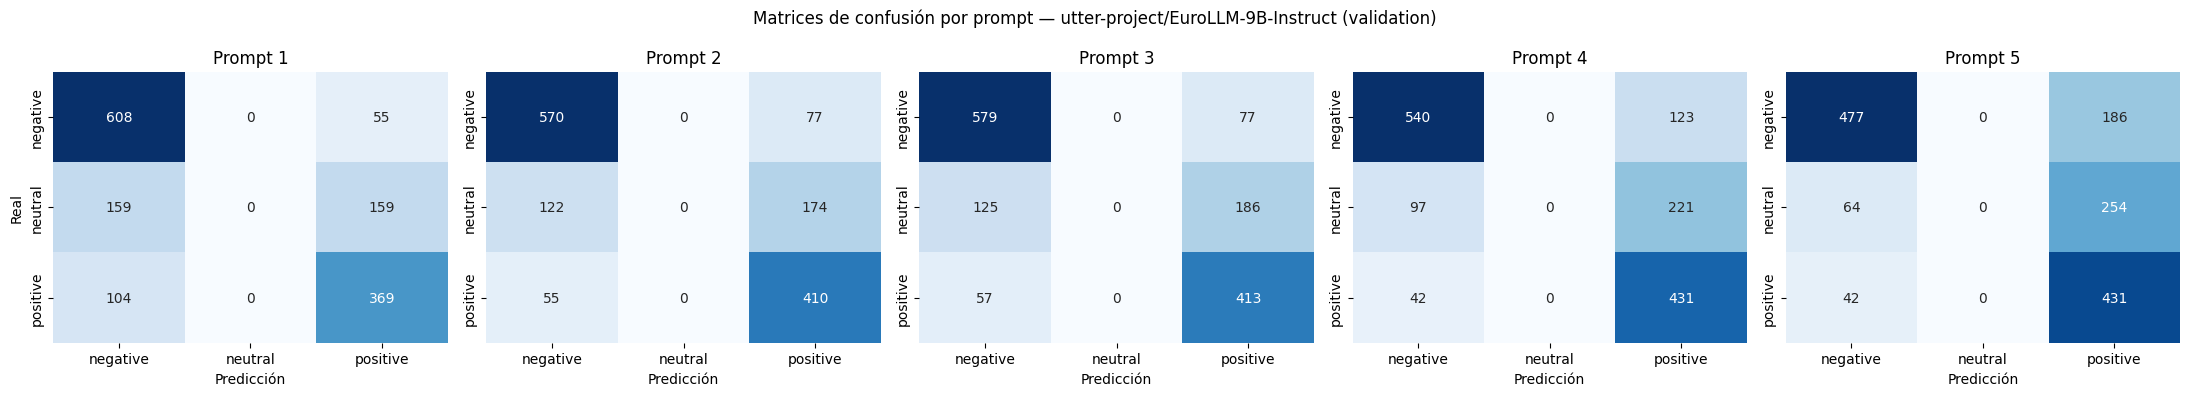

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for i, prompt_id in enumerate(PROMPTS):
    sns.heatmap(
        matrices[prompt_id], annot=True, fmt="d", cmap="Blues",
        xticklabels=CLASES, yticklabels=CLASES, ax=axes[i], cbar=False
    )
    axes[i].set_title(f"Prompt {prompt_id}")
    axes[i].set_xlabel("Predicción")
    if i == 0:
        axes[i].set_ylabel("Real")

plt.suptitle(f"Matrices de confusión por prompt — {MODEL_ID} (validation)")
plt.tight_layout()
plt.savefig(f"matrices_confusion_{MODEL_SHORT_NAME}_validation.png", dpi=150)
plt.show()


# Verificando clase neutral ausente en la clasificacion del modelo

In [17]:
# Verificar directamente qué está prediciendo el modelo para el Prompt 3 (el mejor)
df_prompt3 = resultados_por_prompt[3]
print(df_prompt3["prediccion"].value_counts())
print()

# Ver ejemplos donde el texto real ERA neutral, para ver qué predijo el modelo en esos casos
casos_neutral_real = df_prompt3[df_prompt3["label_name"] == "neutral"]
print("Predicciones del modelo cuando el texto real es neutral:")
print(casos_neutral_real["prediccion"].value_counts())
print()
casos_neutral_real[["text_clean", "label_name", "respuesta_cruda", "prediccion"]].head(10)

prediccion
negative    761
positive    676
invalido     17
Name: count, dtype: int64

Predicciones del modelo cuando el texto real es neutral:
prediccion
positive    186
negative    125
invalido      7
Name: count, dtype: int64



,text_clean,label_name,respuesta_cruda,prediccion
1,Cocoros 🙂. Cuando vivía en talara era mi punto.,neutral,El sentimiento del texto es **positivo**,positive
3,"Fatima, la caminada en tacos fue todo! Ya me v...",neutral,Positivo.,positive
7,Spencer hace que Tacora sea un lugar turístico...,neutral,Positivo,positive
13,"Karo, hay que llevar nuestro arroz con pollo c...",neutral,Positivo,positive
17,"Sergio Ivan bichota, eres tú? 😂",neutral,Positivo,positive
20,Cindy Loa tenemos que comprarnos los polos par...,neutral,Positivo,positive
25,el lobo de crepusculo 🤨,neutral,"El sentimiento del texto ""el lobo de cre",invalido
31,Y donde están las rubias Perú 😅😅😅😅😅,neutral,El sentimiento del texto es **negativo**,negative
36,Vamos ps este año si nos mandamos ya q ThaLíaP...,neutral,Positivo.,positive
37,Yo te viiiii y ese chico de camisa a cuadros s...,neutral,Positivo,positive
